# 02b. Fahy & Gardonio's box, driven

The box of `02_cavity_plate_coupled_FG`, cut finer and pushed: 1 N at the
centre of the plate, coupled response solved line by line to 1000 Hz, then
the same sweep repeated on two reduced bases.

| | |
|---|---|
| cavity | 0.414 x 0.314 x 0.360 m, air, five hard walls |
| plate | 1 mm aluminium, clamped, on the top face |
| mesh | 32 x 24 x 16 `CHEXA8` + 32 x 24 `CQUAD4F`, conforming |
| drive | 1 N along z at the centre of the plate, eta_s = 0.02 |
| methods | direct sweep, then coupled-modal and CMS reduction against it |
| read | displacement at the drive, three microphones, cavity average |

What changes from 02: a finer mesh (theirs stops resolving the plate well
below 1000 Hz) and a point force. Geometry, material and walls are the same.

---
## 1. The run

`from pycafe import *` is the whole import. The plate is written out because
the book's modulus is not pyCAFE's default and its Poisson ratio is not
quoted (0.33 assumed).

`DF` is the cost knob: the direct sweep factorizes a complex unsymmetric
matrix once per line, about 3 s on ~18 000 unknowns.

In [1]:
%matplotlib widget
# every figure below is a live canvas that can be turned with the mouse
# (needs ipympl); drop this line for flat pictures instead.

import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/

import numpy as np
import matplotlib.pyplot as plt

from pycafe import *          # the whole API: models, questions, solvers, plots

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

ANALYSIS = "vibroacoustic"                 # fluid and structure, coupled
FLUID = AIR

# Fahy & Gardonio's aluminium: rho = 2700 kg/m3, E = 7.1e10 N/m2, h = 1 mm,
# clamped on all four edges. nu is not given in the example; 0.33 is used.
STRUCTURE = Structure(t=1.0e-3, E=7.1e10, nu=0.33, rho_s=2700.0,
                      name="aluminium", support="clamped")

F_MAX = 1000.0       # the top of the sweep, and what the mesh is checked against
F_MIN = 20.0         # below the first plate mode
DF = 2.0             # the cost of the run: 491 lines at 2 Hz
FORCE = 1.0          # N, normal to the plate, at its centre
ETA_S = 0.02         # structural loss factor; the air carries no damping

N_MODES = 50         # coupled modes, to mark the lines the sweep should show

frequencies = np.arange(F_MIN, F_MAX + DF, DF)
RHO0, C0 = FLUID.rho0, FLUID.c0

print(f"{ANALYSIS} run in {FLUID.name}, c0 = {C0:.0f} m/s")
print(f"plate: {STRUCTURE.name}, {STRUCTURE.t * 1e3:.1f} mm, "
      f"{STRUCTURE.support}, E = {STRUCTURE.E:.3g} Pa, nu = {STRUCTURE.nu}, "
      f"rho = {STRUCTURE.rho_s:.0f} kg/m3")
print(f"       D = {STRUCTURE.D:.3f} N m, "
      f"mass = {STRUCTURE.rho_s * STRUCTURE.t:.2f} kg/m2")
print(f"sweep: {F_MIN:.0f} to {F_MAX:.0f} Hz in {DF:.1f} Hz steps, "
      f"{frequencies.size} lines")
print(f"drive: {FORCE:.0f} N at the centre of the plate, eta_s = {ETA_S}")

vibroacoustic run in air, c0 = 343 m/s
plate: aluminium, 1.0 mm, clamped, E = 7.1e+10 Pa, nu = 0.33, rho = 2700 kg/m3
       D = 6.640 N m, mass = 2.70 kg/m2
sweep: 20 to 1000 Hz in 2.0 Hz steps, 491 lines
drive: 1 N at the centre of the plate, eta_s = 0.02


---
## 2. The geometry

One file, named here: `Library/cavity_plate_FG_directresponse.msh`. Same box
as 02, conforming interface, twice the elements per plate side and through
the depth.

The plate sets the mesh, not the air: bending waves are much shorter than
sound at the same frequency. Element counts are pinned in
`Library/make_library.py` for about eight elements per bending wavelength.

MeshFile -> cavity_plate_FG_directresponse.msh
  volume   fluid          14025 nodes
  surface  plate            825 nodes
  surface  rigid_walls     2617 nodes
  edge     plate_clamp      112 nodes

largest fluid element 22.5 mm in air: good to ~1% up to 1173 Hz
plate bending wavelength at 1000 Hz: 99 mm, against 343 mm of sound


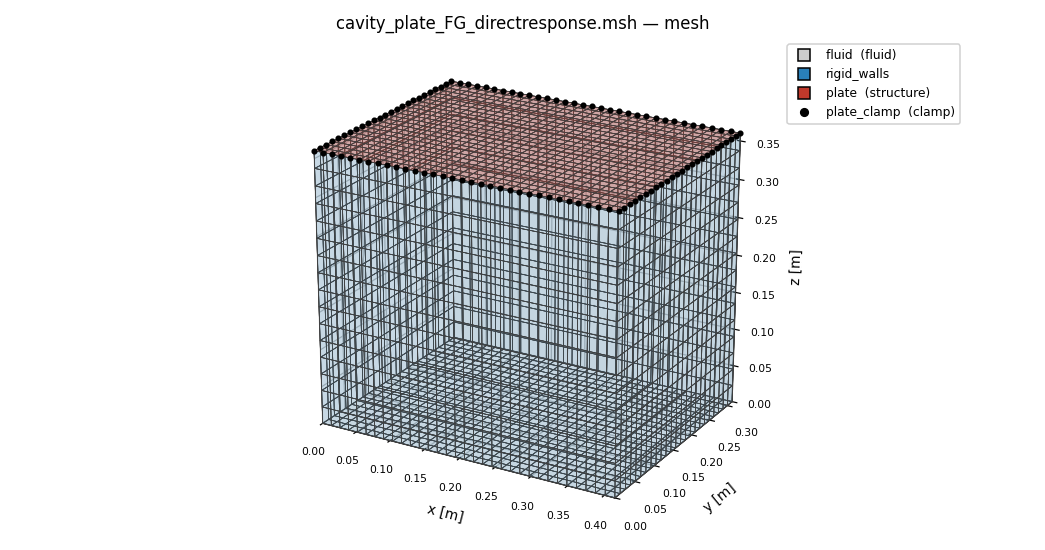

<Axes3D: title={'center': 'cavity_plate_FG_directresponse.msh — mesh'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [2]:
geometry = MeshFile(os.path.join("..", "Library",
                                 "cavity_plate_FG_directresponse.msh"))
picked = os.path.abspath(str(geometry.path))
print(type(geometry).__name__, "->", os.path.basename(picked))

nodes, elements, boundaries, groups = load_mesh_with_groups(picked,
                                                            verbose=False)
for name, group in sorted(groups.items(), key=lambda kv: -kv[1]["dim"]):
    kind = {3: "volume", 2: "surface", 1: "edge"}.get(group["dim"], "?")
    print(f"  {kind:<8} {name:<14} {len(group['nodes']):5d} nodes")

# What this mesh can carry, measured on the elements it already has.
LIMITS = frequency_limits(picked)
if LIMITS is not None:
    print(f"\nlargest fluid element {LIMITS['h_max'] * 1e3:.1f} mm in air: "
          f"good to ~1% up to {LIMITS['f_1pct']:.0f} Hz")
print(f"plate bending wavelength at {F_MAX:.0f} Hz: "
      f"{STRUCTURE.bending_wavelength(F_MAX) * 1e3:.0f} mm, against "
      f"{FLUID.wavelength(F_MAX) * 1e3:.0f} mm of sound")

plot_mesh_3d(nodes, groups, title=f"{os.path.basename(picked)} — mesh")

---
## 3. The model

`build_model` reads the mesh, checks it against `f_max`, draws it by role and
assembles both domains plus the coupling. The line to read is *interface
conforming*: plate quadrilaterals are the top faces of the fluid hexahedra,
so the coupling is assembled face by face with nothing interpolated.

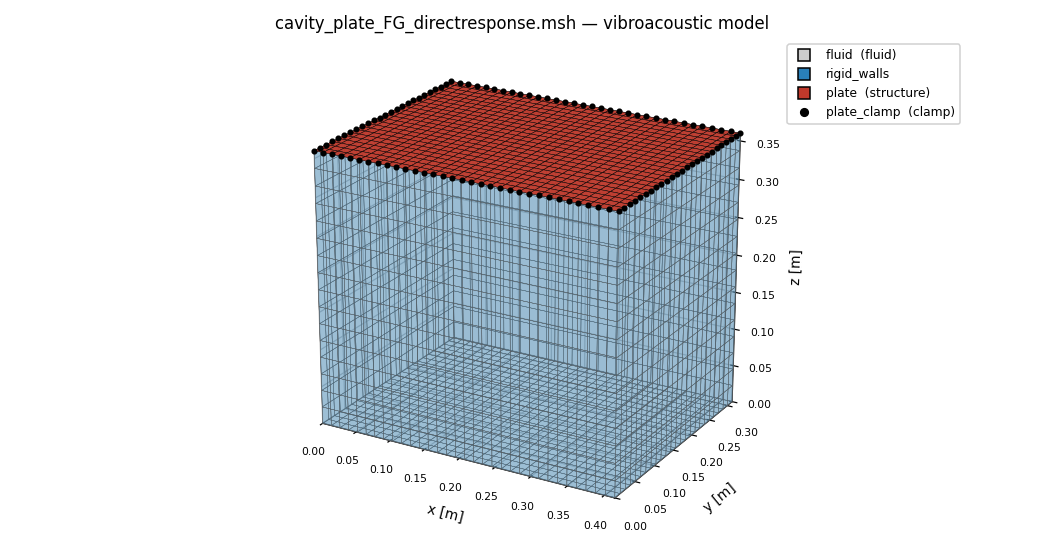

../Library/cavity_plate_FG_directresponse.msh  (vibroacoustic analysis)
-----------------------------------------------------------------------
  14025 nodes, 112 x Line 2, 3328 x Quadrilateral 4, 12288 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 768 faces, one fluid element behind each
  · fluid element size: 22.5 / 22.5 / 22.5 mm (min / mean / max)
  · good to ~1% up to 1173 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 1000 Hz: 15.2 elements per wavelength, dispersion error ~0.71%
  · selectable boundaries: rigid_walls
  => usable
domains in cavity_plate_FG_directresponse.msh (vibroacoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure   group 'plate'          <- aluminium: t = 1.00 mm, E = 71 GPa, nu = 0.33, rho = 2700.0 kg/m3
  support     group 'plate_clamp'    <- clamped (the mesh says which nodes are held, Structure.support says how)
  selectable bo

In [3]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,
    fluid=FLUID,
    structure=STRUCTURE,
    f_max=F_MAX,
    work_dir=".",
)
model = build_model(spec)

nodes = model["nodes"]
elements = model["elements"]
groups = model["groups"]
boundaries = model["boundaries"]
system = model["system"]
report = model["report"]

print(report)
print(describe_domains(report, FLUID, STRUCTURE))

# Where the plate is and how its nodes are laid out: measured, not assumed.
panel = describe_panel(nodes, groups[report.roles["structure"]]["nodes"])
fluid_nodes0 = np.asarray(groups[report.roles["fluid"]]["nodes"], dtype=int) - 1
BOX = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
LX, LY, LZ = (a[-1] - a[0] for a in BOX)

print(f"\nplate      {panel}")
print(f"           elements {panel.spacing[0] * 1e3:.1f} x "
      f"{panel.spacing[1] * 1e3:.1f} mm, "
      f"{STRUCTURE.bending_wavelength(F_MAX) / max(panel.spacing):.1f} across "
      f"a bending wavelength at {F_MAX:.0f} Hz")
print(f"cavity     {LX:.3f} x {LY:.3f} x {LZ:.3f} m"
      f"   (Fahy & Gardonio: 0.414 x 0.314 x 0.360 m)")
print(f"unknowns   {system['structural']['idx_free'].size} structural + "
      f"{system['acoustic']['nodes0'].size} acoustic")

---
## 4. Where the peaks should be

Fifty coupled modes, computed once, to mark the lines the sweep should show.
They are undamped: they say where the peaks are, not how tall.

The 0 Hz uniform pressure of the sealed box is a genuine solution and stays
in the model — it is the air spring the plate works against — but it is not
a resonance, so it is left out of the lines drawn below.

In [4]:
blocks_free = build_coupled_blocks(system)     # hard walls: nothing is added

t0 = time.time()
f_modal, coupled_shapes = solve_vibroacoustic_modal(system, num_modes=N_MODES,
                                                    blocks=blocks_free)
resonances = f_modal[f_modal > 1.0]
inside = resonances[resonances <= F_MAX]

print(f"{f_modal.size} coupled modes in {time.time() - t0:.1f} s, "
      f"{blocks_free['n_s']} structural + {blocks_free['n_a']} acoustic "
      "unknowns")
print(f"{inside.size} of them inside the sweep, from {inside[0]:.1f} to "
      f"{inside[-1]:.1f} Hz; the basis reaches {f_modal[-1]:.0f} Hz")
for row in range(0, inside.size, 6):
    print("  " + "  ".join(f"{f:8.1f}" for f in inside[row:row + 6]))

50 coupled modes in 2.0 s, 4278 structural + 14025 acoustic unknowns
39 of them inside the sweep, from 82.9 to 995.3 Hz; the basis reaches 1154 Hz
      82.9     121.6     169.7     206.1     216.0     294.8
     319.8     322.0     365.1     406.5     418.4     441.5
     464.7     487.3     524.3     547.5     550.1     556.8
     572.0     630.2     646.6     655.0     686.8     692.0
     729.6     731.1     752.6     794.8     830.3     839.0
     839.1     864.6     868.9     891.7     911.5     944.8
     961.6     962.9     995.3


---
## 5. What drives it: 1 N at the centre

`structural_point_load` turns "one newton on that node along the normal" into
a vector on the free structural DOFs — a search in `idx_free` first, since
the clamped rim has no DOF to push.

The centre is a strong place and a blind one: a mode with a nodal line
through the middle is pushed exactly on its node and stays out of the
response. The table reads that off the coupled modes, as the displacement at
the drive relative to each mode's own peak. Those near zero are the modes
section 8 will not find.

In [5]:
structural_nodes0 = np.unique(system["structural"]["idx_free"] // 6)
centre = panel.centre()
DRIVE_NODE = int(structural_nodes0[np.argmin(
    np.linalg.norm(nodes[structural_nodes0] - centre, axis=1))])
F_s, dof = structural_point_load(system, DRIVE_NODE, FORCE, panel.normal)

print(f"drive      node {DRIVE_NODE} at "
      f"{np.round(nodes[DRIVE_NODE], 4)} m, {FORCE:.0f} N along "
      f"{'xyz'[panel.normal]}")
print(f"           the centre of the plate is at {np.round(centre, 4)} m, "
      f"{np.linalg.norm(nodes[DRIVE_NODE] - centre) * 1e3:.1f} mm away")

# How much each coupled mode moves at the drive point, against its own peak.
# Only the out-of-plane translations are compared: a shell node also carries
# rotations, and radians against metres would set the scale of a ratio that
# then says nothing about the shape.
n_s = blocks_free["n_s"]
idx_s = np.asarray(system["structural"]["idx_free"], dtype=int)
normal_rows = np.where(idx_s % 6 == panel.normal)[0]
w_modes = np.real(coupled_shapes[:n_s])
at_drive = (np.abs(w_modes[dof])
            / np.maximum(np.abs(w_modes[normal_rows]).max(axis=0), 1e-30))

flexible = np.where((f_modal > 1.0) & (f_modal <= F_MAX))[0]
driven = [i for i in flexible if at_drive[i] >= 0.05]
blind = [i for i in flexible if at_drive[i] < 0.05]

print(f"\n{len(driven)} of the {flexible.size} modes inside the sweep move at "
      f"the drive point;\n{len(blind)} are nodal there and no force at the "
      "centre can reach them")
print(f"\n  {'f [Hz]':>9} {'w(drive) / w(peak)':>20}")
for i in flexible:
    print(f"  {f_modal[i]:9.1f} {at_drive[i]:20.2f}"
          + ("" if at_drive[i] >= 0.05 else "   nodal at the drive"))

drive      node 1353 at [0.207 0.157 0.36 ] m, 1 N along z
           the centre of the plate is at [0.207 0.157 0.36 ] m, 0.0 mm away

13 of the 39 modes inside the sweep move at the drive point;
26 are nodal there and no force at the centre can reach them

     f [Hz]   w(drive) / w(peak)
       82.9                 1.00
      121.6                 0.00   nodal at the drive
      169.7                 0.00   nodal at the drive
      206.1                 0.93
      216.0                 0.00   nodal at the drive
      294.8                 0.00   nodal at the drive
      319.8                 0.00   nodal at the drive
      322.0                 0.96
      365.1                 0.00   nodal at the drive
      406.5                 0.00   nodal at the drive
      418.4                 0.00   nodal at the drive
      441.5                 0.98
      464.7                 0.88
      487.3                 1.00
      524.3                 0.00   nodal at the drive
      547.5             

---
## 6. The sweep

The coupled system solved as it stands at every line. Nothing projected,
nothing truncated: the answer is the mesh's. The price is one factorization
per frequency, hence the progress blocks below.

Only the plate is damped. The air carries no loss and the walls are hard, so
the cavity-controlled peaks are as tall as the sweep step lets them be.

Three microphones: a corner (antinode of every cavity mode), the middle of
the cavity, and the floor under the drive point.

In [6]:
blocks = build_coupled_blocks(system, eta_s=ETA_S)   # the damped run

# The microphones, as the nearest fluid node to each place asked for.
WANTED = {"corner": (0.0, 0.0, 0.0),
          "cavity centre": (LX / 2, LY / 2, LZ / 2),
          "floor under the drive": (centre[0], centre[1], 0.0)}
MICS = {}
for name, xyz in WANTED.items():
    node0 = int(fluid_nodes0[np.argmin(
        np.linalg.norm(nodes[fluid_nodes0] - xyz, axis=1))])
    MICS[name] = (node0, nodes[node0])
    print(f"  {name:<22} node {node0:6d} at {np.round(nodes[node0], 3)} m")

# The sweep in blocks, so that a run of this length says where it is.
t0 = time.time()
w_all, p_all = [], []
for start in range(0, frequencies.size, 50):
    chunk = frequencies[start:start + 50]
    part = solve_vibroacoustic_frequency_sweep(system, chunk, F_s=F_s,
                                               blocks=blocks, verbose=False)
    w_all.append(part["w"])
    p_all.append(part["p"])
    done = start + chunk.size
    print(f"  {done:4d}/{frequencies.size} lines, up to {chunk[-1]:6.1f} Hz, "
          f"{time.time() - t0:6.1f} s")

w = np.hstack(w_all)
p = np.hstack(p_all)
p_sweep = expand_pressure(p, blocks["idx_a"], nodes.shape[0])
w_drive = w[dof]

print(f"\n{frequencies.size} frequencies in {time.time() - t0:.1f} s, "
      f"{blocks['n_s'] + blocks['n_a']} unknowns, "
      f"{(time.time() - t0) / frequencies.size:.2f} s per line")

  corner                 node      0 at [0. 0. 0.] m
  cavity centre          node   8677 at [0.207 0.157 0.18 ] m
  floor under the drive  node    640 at [0.207 0.157 0.   ] m


    50/491 lines, up to  118.0 Hz,  144.8 s


   100/491 lines, up to  218.0 Hz,  310.8 s


   150/491 lines, up to  318.0 Hz,  476.8 s


   200/491 lines, up to  418.0 Hz,  642.8 s


...

   300/491 lines, up to  618.0 Hz,  983.7 s


   350/491 lines, up to  718.0 Hz, 1162.9 s


   400/491 lines, up to  818.0 Hz, 1340.2 s


   450/491 lines, up to  918.0 Hz, 1520.5 s


   491/491 lines, up to 1000.0 Hz, 1669.2 s

491 frequencies in 1669.2 s, 18303 unknowns, 3.40 s per line


---
## 7. Reading it

Three quantities, one panel each, never two scales on one frame:

* the plate at the drive point, a receptance in m/N;
* the three microphones, one panel with a legend;
* the whole cavity, the volume-averaged pressure, which the acoustic mass
  matrix gives for nothing.

The average is what a coupled run is usually asked for, and unlike a
microphone it cannot sit on a node. Grey lines are the modes of section 4.

peak |w| at the drive     2.411 mm/N at 82 Hz
peak |p|, corner                   813.56 Pa at 962 Hz
peak |p|, cavity centre            260.89 Pa at 82 Hz
peak |p|, floor under the drive    515.41 Pa at 962 Hz
loudest cavity average    141.8 dB re 20 uPa at 962 Hz
most power into the plate 347.96 mW at 82 Hz


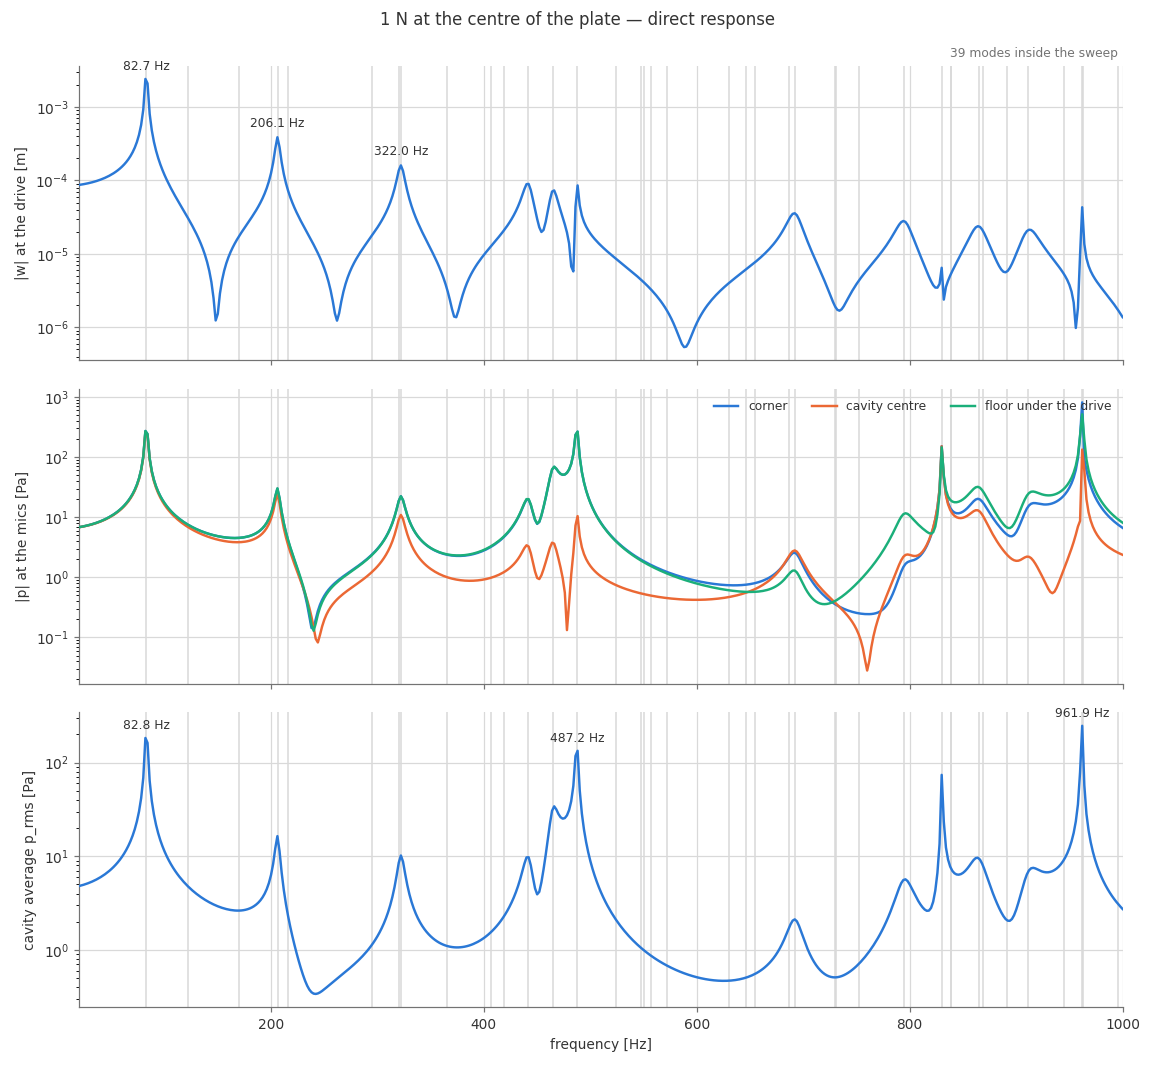

[<Axes: ylabel='|w| at the drive [m]'>,
 <Axes: ylabel='|p| at the mics [Pa]'>,
 <Axes: xlabel='frequency [Hz]', ylabel='cavity average p_rms [Pa]'>]

In [7]:
response = {name: p_sweep[node0] for name, (node0, _) in MICS.items()}

# Space-averaged mean square pressure, straight off the acoustic mass matrix.
Ma = blocks["Ma"]
mean_square = (np.einsum("ij,ij->j", p.conj(), Ma @ p).real
               / Ma.sum() / 2.0)              # /2: amplitude to mean square
p_rms = np.sqrt(np.maximum(mean_square, 0.0))
spl = 20 * np.log10(np.maximum(p_rms, 1e-12) / 2e-5)

# Power the force puts into the plate: half the real part of F times the
# conjugate velocity, and the velocity is j omega w.
velocity = 1j * 2 * np.pi * frequencies * w_drive
power_in = 0.5 * np.real(FORCE * np.conj(velocity))

print(f"peak |w| at the drive     {np.abs(w_drive).max() * 1e3:.3f} mm/N at "
      f"{frequencies[np.argmax(np.abs(w_drive))]:.0f} Hz")
for name, values in response.items():
    print(f"peak |p|, {name:<22} {np.abs(values).max():8.2f} Pa at "
          f"{frequencies[np.argmax(np.abs(values))]:.0f} Hz")
print(f"loudest cavity average    {spl.max():.1f} dB re 20 uPa at "
      f"{frequencies[np.argmax(spl)]:.0f} Hz")
print(f"most power into the plate {power_in.max() * 1e3:.2f} mW at "
      f"{frequencies[np.argmax(power_in)]:.0f} Hz")

plot_frf(frequencies,
         {"|w| at the drive [m]": w_drive,
          "|p| at the mics [Pa]": response,
          "cavity average p_rms [Pa]": p_rms},
         resonances=inside,
         title=f"{FORCE:.0f} N at the centre of the plate — direct response",
         show=True)

### 7b. The field at the loudest line

One picture, at the frequency where the cavity average is highest, with the
microphones marked in the colours their curves wear above. A magnitude, so a
single hue.

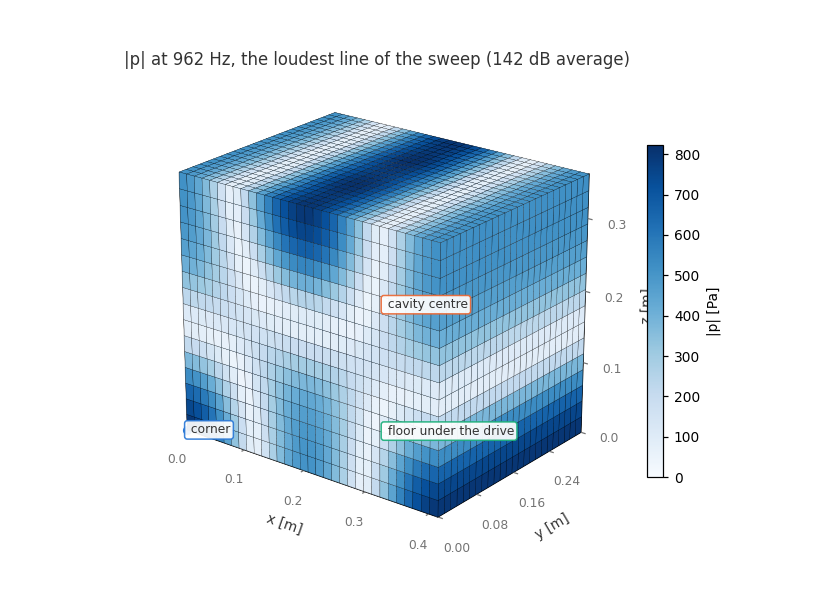

<Axes3D: title={'center': '|p| at 962 Hz, the loudest line of the sweep (142 dB average)'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [8]:
loudest = int(np.argmax(spl))
plot_field(nodes, elements, p_sweep[:, loudest], part="abs", show=True,
           markers={name: xyz for name, (_, xyz) in MICS.items()},
           title=f"|p| at {frequencies[loudest]:.0f} Hz, the loudest line "
                 f"of the sweep ({spl[loudest]:.0f} dB average)")

---
## 8. Every peak on a mode, and the modes with no peak

The check the sweep is worth running for. A peak on no mode is an artefact or
a mode the list stopped short of; a mode with no peak is not an error —
section 5 already named the ones a centred force cannot reach.

In [9]:
signals = {"w": w_drive, "p_rms": p_rms,
           **{name.split()[0]: values for name, values in response.items()}}
peaks = find_response_peaks(frequencies, signals)

# Three steps of the sweep, or half a percent of the top: an undamped cavity
# peak sampled at DF lands within a step or two of where the mode is.
tolerance = max(3 * DF, 0.005 * F_MAX)

print(f"{len(peaks)} peaks against {inside.size} modes inside the sweep, "
      f"paired within {tolerance:.0f} Hz\n")
print(f"{'peak [Hz]':>10} {'seen in':>22} {'mode [Hz]':>12} {'difference':>12}")
for f_peak, seen in peaks:
    gap = np.abs(inside - f_peak)
    near = inside[int(np.argmin(gap))] if gap.min() <= tolerance else None
    cell = f"{near:12.2f}" if near is not None else f"{'none':>12}"
    gap_cell = (f"{f_peak - near:12.2f}" if near is not None else f"{'':>12}")
    print(f"{f_peak:10.2f} {'+'.join(sorted(seen)):>22} {cell}{gap_cell}")

missing = missing_from_response(peaks, inside, tolerance=tolerance)
predicted = {round(float(f_modal[i]), 1) for i in blind}
unexplained = [f for f in missing if round(float(f), 1) not in predicted]

print(f"\n{len(missing)} modes inside the sweep have no peak of their own: "
      + (", ".join(f"{f:.1f}" for f in missing) if len(missing) else "none")
      + " Hz")
print(f"{len(missing) - len(unexplained)} of them are the ones section 5 "
      "called nodal at the drive"
      + ("." if not unexplained else
         ", the rest are not: "
         + ", ".join(f"{f:.1f} Hz" for f in unexplained)))

13 peaks against 39 modes inside the sweep, paired within 6 Hz

 peak [Hz]                seen in    mode [Hz]   difference
     82.74 cavity+corner+floor+p_rms+w        82.92       -0.18
    206.07 cavity+corner+floor+p_rms+w       206.13       -0.06
    321.96 cavity+corner+floor+p_rms+w       322.02       -0.06
    441.07 cavity+corner+floor+p_rms+w       441.55       -0.47
    465.35 cavity+corner+floor+p_rms+w       464.66        0.68
    488.03 cavity+corner+floor+p_rms+w       487.31        0.72
    691.49 cavity+corner+floor+p_rms+w       692.05       -0.56
    794.09   cavity+floor+p_rms+w       794.80       -0.71
    829.67 cavity+corner+floor+p_rms+w       830.26       -0.59
    864.24 cavity+corner+floor+p_rms+w       864.61       -0.38
    912.69   cavity+floor+p_rms+w       911.46        1.23
    916.91                 corner       911.46        5.44
    962.13 cavity+corner+floor+p_rms+w       961.57        0.56

23 modes inside the sweep have no peak of their own: 121.6

---
## 9. The two reductions against it

Both reduced solvers expand the response on a small basis and solve an
`m x m` system per line instead of an 18 000 x 18 000 one — seconds instead
of half an hour. Same number of vectors here, so what differs is the basis.

* **Coupled modes** (`build_coupled_modal_basis`) — modes of the whole
  fluid-structure system. Expensive to build (one large unsymmetric
  eigenproblem) and the most efficient per vector: the coupling is already
  inside each mode.
* **CMS** (`build_cms_basis`) — plate *in vacuo* plus the sealed hard-walled
  cavity, two symmetric eigenproblems, coupling put back only in the reduced
  matrices. Cheap to build, less efficient: hard-wall modes reconstruct the
  field next to a moving plate slowly.

Read the two error columns together. A point force is the broadest load there
is in space, so the drive point is the worst place to judge a truncated
basis, while the cavity average — smooth, and an average — is much closer.
That gap is what the direct sweep buys out.

In [ ]:
# Same basis size for both, so the comparison is about the basis and not
# about its length: 2 x f_max is the usual truncation rule.
M_S, M_A = 60, 120                 # CMS: plate modes + hard-wall cavity modes
M_C = M_S + M_A                    # coupled modes, the same count

builders = {
    "coupled": lambda: build_coupled_modal_basis(blocks=blocks_free,
                                                 num_modes=M_C),
    "CMS":     lambda: build_cms_basis(blocks=blocks_free,
                                       num_structural=M_S, num_acoustic=M_A),
}

REDUCED = {}
for label, build in builders.items():
    t0 = time.time()
    basis = build()
    t_build = time.time() - t0

    t0 = time.time()
    out = solve_coupled_modal_frequency_sweep(basis, frequencies, F_s=F_s,
                                              eta_s=ETA_S)
    t_sweep = time.time() - t0

    p_r = out["p"]
    REDUCED[label] = {
        "w": out["w"][dof],
        "p_rms": np.sqrt(np.maximum(
            np.einsum("ij,ij->j", p_r.conj(), Ma @ p_r).real
            / Ma.sum() / 2.0, 0.0)),
        "t_build": t_build,
        "t_sweep": t_sweep,
        "m": basis["Phi_R"].shape[1],
        "f_top": float(basis["freqs"].max()),
    }
    print(f"{label:<8} {REDUCED[label]['m']:4d} vectors reaching "
          f"{REDUCED[label]['f_top']:6.0f} Hz, "
          f"basis {t_build:6.1f} s + sweep {t_sweep:5.1f} s "
          f"against ~{frequencies.size * 3.2 / 60:.0f} min direct")

# Error against the direct sweep, as a fraction of that curve's own peak.
print(f"\n{'':<8} {'|w| at the drive':>26} {'cavity average':>26}")
print(f"{'':<8} {'worst':>12} {'median':>13} {'worst':>12} {'median':>13}")
for label, run in REDUCED.items():
    cells = []
    for exact, approx in ((w_drive, run["w"]), (p_rms, run["p_rms"])):
        err = np.abs(np.abs(approx) - np.abs(exact)) / np.abs(exact).max()
        cells += [f"{100 * err.max():11.1f}%", f"{100 * np.median(err):12.2f}%"]
    print(f"{label:<8} " + " ".join(cells))

plot_frf(frequencies,
         {"|w| at the drive [m]": {"direct": w_drive,
                                   "coupled": REDUCED["coupled"]["w"],
                                   "CMS": REDUCED["CMS"]["w"]},
          "cavity average p_rms [Pa]": {"direct": p_rms,
                                        "coupled": REDUCED["coupled"]["p_rms"],
                                        "CMS": REDUCED["CMS"]["p_rms"]}},
         resonances=inside, title="Direct against both reduced bases",
         show=True)

---
## What to take away

* **The mesh is part of the frequency.** 02's coarse mesh answers eighteen
  modes and nothing above; 1000 Hz needs the plate cut for its bending
  wavelength, which is what fixes 32 x 24 x 16 here.
* **A direct sweep has no basis to be wrong about** — one factorization per
  line, and that is the whole of what it costs.
* **Both reductions buy the same thing at different prices.** Coupled modes
  cost a large unsymmetric eigenproblem and track the direct curve best per
  vector; CMS costs two symmetric ones and needs more vectors for the same
  accuracy near the plate.
* **Where the force is decides what answers.** At the centre, every mode with
  a nodal line through the middle is pushed on its node. Section 5 predicts
  it, section 8 finds it.
* **Damp what you claim to have damped.** eta_s is the plate's; the air and
  the walls carry none.
* **Read the cavity, not one node of it.** The space average cannot sit on a
  nodal surface the way a microphone can.

The modes of this box against Fahy & Gardonio's table are in
`02_cavity_plate_coupled_FG.ipynb`. A run on any geometry, boundaries and
drive asked rather than pinned, is `03_any_geometry_any_analysis.ipynb`.